# Reddit data analysis and preprocessing

In [104]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

from social_graph.describe import persona_significance
from social_graph.metrics import cramers_v_matrix
from social_graph.preprocessing import *

In [71]:
users = pd.read_csv('data/Reddit_data/author_profiles.csv')
users.head()

,author,mbti,introverted,intuitive,thinking,perceiving,gender,age,enneagram,country,...,enneagram_wing,is_native_english_country,predicted_test,test_name,test_scale,16pers_ta,test_result_type,is_female,is_female_pred,is_female_proba
0,-Afrodisiac-,intp,1.0,1.0,1.0,1.0,m,19.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1,0.531728
1,-Areopagan-,NaN,NaN,NaN,NaN,NaN,m,NaN,NaN,NaN,...,NaN,NaN,0.0,understand myself,percentiles,NaN,percentiles,0.0,0,0.162758
2,-Automaticity,entp,0.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.013042
3,-Avacyn,entj,0.0,1.0,1.0,0.0,f,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1,0.727445
4,-Avatar-Korra-,intp,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.068694


In [72]:
len(users)

10295

In [73]:
# users.isnull().sum()

### Keep only users with Big Five columns not null

In [74]:
big_five_cols = ['agreeableness', 'openness', 'conscientiousness', 'extraversion', 'neuroticism']

valid_users = users[
    users[big_five_cols].notnull().all(axis=1)
]

len(valid_users)

1568

In [75]:
valid_users.isnull().sum()

author                          0
mbti                         1175
introverted                  1181
intuitive                    1175
thinking                     1178
perceiving                   1185
gender                        954
age                           930
enneagram                    1504
country                      1333
state                        1489
type                            0
agreeableness                   0
openness                        0
conscientiousness               0
extraversion                    0
neuroticism                     0
is_description               1424
is_percentile                1200
is_score                      506
contains_details              218
num_comments                    0
en_comments                     0
en_comments_percentage          0
region                       1494
continent                    1333
country_code                 1333
enneagram_type               1504
enneagram_wing               1505
is_native_engl

In [76]:
cols_to_keep = ["author", "agreeableness", "openness", "conscientiousness", "extraversion", "neuroticism", "gender", "age", "num_comments"]

valid_users = valid_users[cols_to_keep]
valid_users.describe()

,agreeableness,openness,conscientiousness,extraversion,neuroticism,age,num_comments
count,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,638.000000,1568.000000
mean,42.147003,62.536033,40.232143,37.147321,49.874043,26.181818,2553.105867
std,30.966034,27.807625,30.374644,30.460500,32.367686,7.957196,5538.815631
min,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,1.000000
25%,13.000000,43.750000,13.000000,10.000000,18.750000,20.000000,119.750000
50%,39.250000,69.000000,35.000000,30.000000,50.000000,24.000000,642.500000
75%,70.000000,86.000000,65.000000,60.000000,82.000000,30.000000,2450.500000
max,100.000000,100.000000,99.000000,99.000000,100.000000,64.000000,77866.000000


Create set of valid usernames

In [77]:
valid_usernames = set(
    valid_users["author"].astype(str)
)
# valid_usernames

### Add Big Five persona

In [78]:
features_cols = ["agreeableness", "openness", "conscientiousness", "extraversion", "neuroticism"]

features_df = valid_users[features_cols]

scaler = StandardScaler()
features_df = scaler.fit_transform(features_df)

#### KMeans

k=2 silhouette=0.1876
k=3 silhouette=0.1811
k=4 silhouette=0.1762
k=5 silhouette=0.1771
k=6 silhouette=0.1797
k=7 silhouette=0.1837
k=8 silhouette=0.1849
k=9 silhouette=0.1915


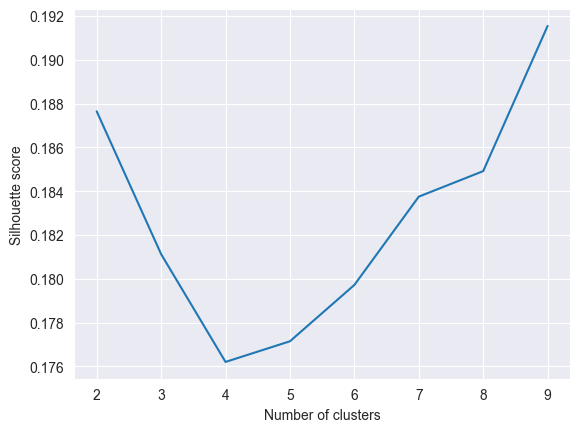

In [79]:
search_best_number_of_personae(features_df)

In [111]:
valid_users = create_personae(5, valid_users, features_df)

persona
Persona_3    334
Persona_2    319
Persona_4    313
Persona_1    303
Persona_5    299
Name: count, dtype: int64


In [112]:
valid_users.drop(['author', 'gender'], axis=1, inplace=False).groupby('persona').mean()

,agreeableness,openness,conscientiousness,extraversion,neuroticism,age,num_comments,hier_cluster
persona,,,,,,,,
Persona_1,41.008251,74.075908,20.764026,75.681518,41.737624,26.521008,2945.382838,1.471947
Persona_2,77.288401,72.427900,38.484326,22.467085,67.087774,27.154930,2926.062696,0.815047
Persona_3,19.517964,71.332335,20.434132,17.353293,66.517964,25.055556,2484.556886,0.416168
Persona_4,38.646965,72.105431,78.645367,53.615016,24.207668,26.975207,2259.386581,1.507987
Persona_5,34.750836,20.444816,43.729097,18.632107,48.030100,25.178571,2141.722408,1.816054


- Persona 1 – Social Explorers: highly extraverted and open individuals with low conscientiousness and relatively low neuroticism. These users are likely to be socially active, exploratory, and frequent content creators.
- Persona 2 – Anxious Introverts: users characterized by very high neuroticism, low extraversion, and low conscientiousness. This group may represent emotionally reactive but socially withdrawn individuals with lower participation intensity.
- Persona 3 – Reserved Conventionalists: users with low openness and low extraversion combined with moderate neuroticism. These individuals appear more conservative, less socially engaged, and less exploratory.
- Persona 4 – Structured Socializers: users with very high conscientiousness, high openness, moderate extraversion, and low neuroticism. This persona likely represents emotionally stable and organized individuals who engage socially in a more structured manner.

#### Hierarchical clustering

k=2 silhouette=0.1526
k=3 silhouette=0.1280
k=4 silhouette=0.1280
k=5 silhouette=0.1072
k=6 silhouette=0.1170
k=7 silhouette=0.1184
k=8 silhouette=0.1309
k=9 silhouette=0.1366


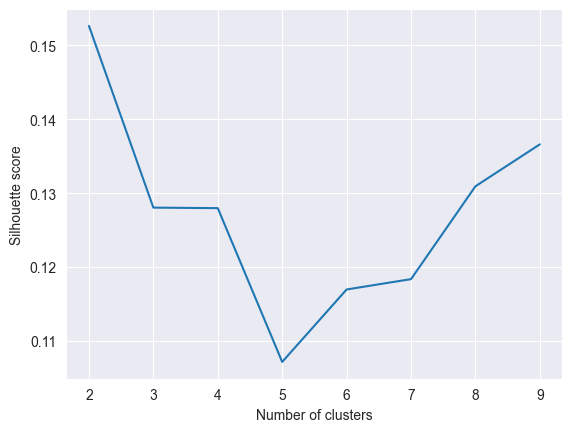

In [117]:
scores = []

for k in range(2, 10):
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(features_df)
    score = silhouette_score(features_df, labels)
    scores.append(score)
    print(f"k={k} silhouette={score:.4f}")

plt.plot(range(2, 10), scores)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

In [82]:
model = AgglomerativeClustering(
    n_clusters=4,          # same as KMeans for comparison
    linkage='ward'         # best default
    # linkage='average'   # more flexible
    # linkage='complete'  # tighter clusters
)

labels = model.fit_predict(features_df)

In [83]:
valid_users['hier_cluster'] = labels

<Axes: >

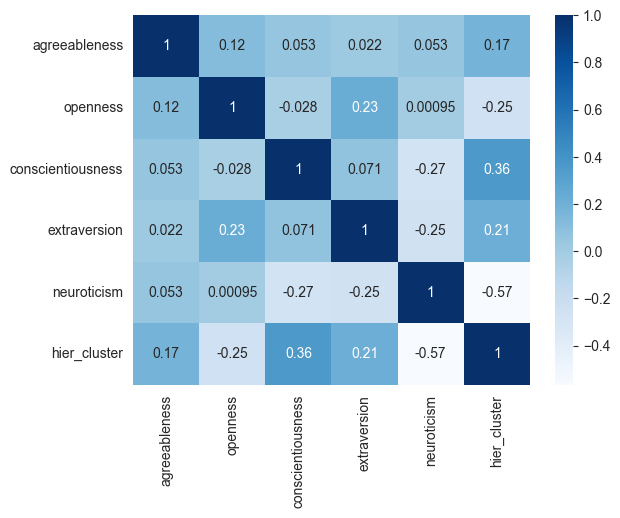

In [110]:
corr = valid_users[features_cols + ['hier_cluster']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')

In [84]:
valid_users.head()

,author,agreeableness,openness,conscientiousness,extraversion,neuroticism,gender,age,num_comments,persona,hier_cluster
1,-Areopagan-,0.0,99.0,96.0,60.0,1.0,m,NaN,5,Persona_4,1
6,-BigSexy-,39.0,92.0,1.0,18.0,4.0,m,23.0,2797,Persona_1,1
7,-BlitzN9ne,50.0,85.0,15.0,50.0,30.0,m,21.0,3404,Persona_1,2
8,-CrestiaBell,50.0,85.0,50.0,85.0,50.0,m,21.0,8106,Persona_1,2
23,-dyad-,60.0,67.0,45.0,10.0,47.0,f,NaN,235,Persona_2,1


In [86]:
adjusted_rand_score(valid_users['hier_cluster'], valid_users['persona'])

0.23596533882683185

#### Compare by PCA plots

In [88]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features_df)

In [91]:
plot_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'kmeans': valid_users['persona'],
    'hierarchical': valid_users['hier_cluster']
})

In [95]:
def plot_pca(plot_df, colour_by=None, title='PCA'):
    # unique interests
    features = plot_df[colour_by].unique()
    # assign colors
    cmap = plt.cm.get_cmap('tab20', len(features))

    plt.figure(figsize=(8, 6))
    for i, colour in enumerate(features):
        subset = plot_df[plot_df[colour_by] == colour]

        plt.scatter(
            subset['PC1'],
            subset['PC2'],
            label=colour,
            alpha=0.7
        )

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

C:\Users\magda\AppData\Local\Temp\ipykernel_29980\2237154511.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(features))


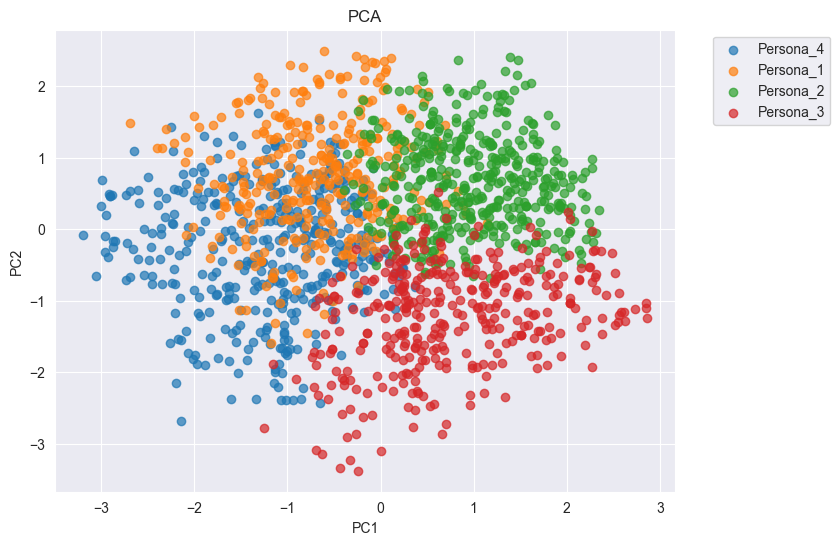

In [96]:
plot_pca(plot_df, colour_by='kmeans')

C:\Users\magda\AppData\Local\Temp\ipykernel_29980\2237154511.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(features))


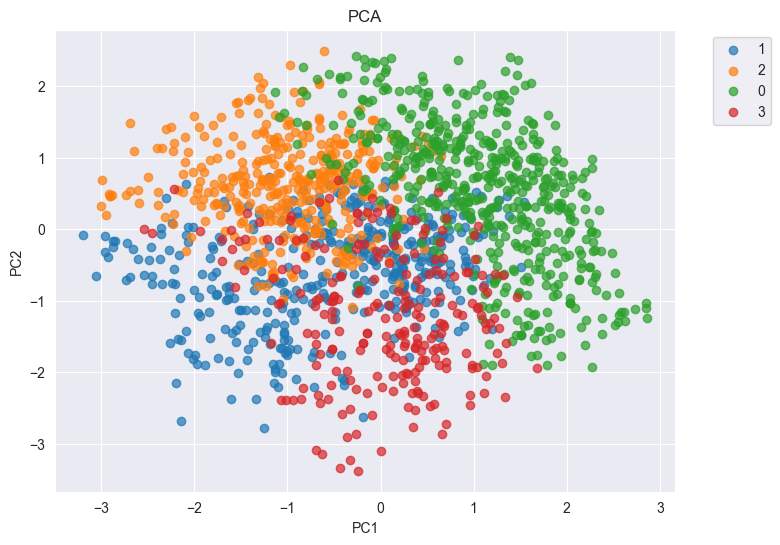

In [97]:
plot_pca(plot_df, colour_by='hierarchical')

In [101]:
sil_kmeans = silhouette_score(features_df, valid_users['persona'])
sil_hier = silhouette_score(features_df, valid_users['hier_cluster'])

print(sil_kmeans)
print(sil_hier)

0.17620454738971628
0.12797511939293946


In [13]:
valid_users.head()

,author,agreeableness,openness,conscientiousness,extraversion,neuroticism,gender,age,num_comments,persona
1,-Areopagan-,0.0,99.0,96.0,60.0,1.0,m,NaN,5,Persona_4
6,-BigSexy-,39.0,92.0,1.0,18.0,4.0,m,23.0,2797,Persona_1
7,-BlitzN9ne,50.0,85.0,15.0,50.0,30.0,m,21.0,3404,Persona_1
8,-CrestiaBell,50.0,85.0,50.0,85.0,50.0,m,21.0,8106,Persona_1
23,-dyad-,60.0,67.0,45.0,10.0,47.0,f,NaN,235,Persona_2


In [14]:
# valid_users.to_csv('data/Reddit_data/filtered_authors.csv', index=False)

Here kmeans is better.

### Filter comments by chunks

In [15]:
chunksize = 100000

input_file = "data/Reddit_data/all_comments_since_2015.csv"
output_file = "data/Reddit_data/filtered_comments.csv"

In [16]:
# first_chunk = True
#
# for i, chunk in enumerate(
#     pd.read_csv(input_file, chunksize=chunksize)
# ):
#
#     print(f"Processing chunk {i}")
#
#     chunk["author"] = chunk["author"].astype(str)
#
#     chunk["created_date"] = pd.to_datetime(
#         chunk["created_utc"],
#         unit="s",
#         errors="coerce"
#     )
#
#     keep_cols = ["author", "body", "created_date", "subreddit", "score"]
#
#     filtered = chunk[
#         (chunk["author"].isin(valid_usernames)) &
#         (chunk["created_date"] >= "2018-01-01")
#     ][keep_cols]
#
#     filtered["created_date"] = filtered["created_date"].dt.strftime("%Y-%m-%d %H:%M:%S")
#
#     filtered.to_csv(
#         output_file,
#         mode="w" if first_chunk else "a",
#         header=first_chunk,
#         index=False
#     )
#
#     first_chunk = False
#
#     print("Saved rows:", len(filtered))
#
# print("DONE")

In [17]:
comments = pd.read_csv("data/Reddit_data/filtered_comments.csv")
comments.head()

,author,body,created_date,subreddit,score
0,UnsaturatedSolution,Doesn't change the fact that OP is a garbage a...,2018-09-06 03:47:52,unpopularopinion,0.0
1,nrjk,"If more SJW's looked like Alyssa Milano, I *mi...",2018-09-29 14:11:45,The_Donald,1.0
2,KopiTheKitten,It never goes away,2018-09-22 14:35:54,octopathtraveler,6.0
3,Incaendo,What about your boss? Risking a job if you thi...,2018-09-11 14:39:12,atheism,2.0
4,britboy3456,Content,2018-09-23 18:48:01,MHOLVote,1.0


In [18]:
len(comments)

901415

## Features engineering

In [19]:
comments_num = (
    comments.groupby('author')
    .size()
    .reset_index(name='comment_count')
)
# comments_num.head()
len(comments_num)

1328

Only 1328 of valid users are authors of at least one comment. We'll these users.

In [20]:
features = valid_users[['author', 'persona', 'num_comments']]
features = features.merge(comments_num, on='author', how='inner')
features.head()

,author,persona,num_comments,comment_count
0,-Areopagan-,Persona_4,5,2
1,-BigSexy-,Persona_1,2797,531
2,-BlitzN9ne,Persona_1,3404,139
3,-CrestiaBell,Persona_1,8106,4321
4,-dyad-,Persona_2,235,58


*num_comments* from valid_users table probably counts all user's comments, including these before 2018. We'll keep only a new count.

In [21]:
features.drop(columns=['num_comments'], inplace=True)
features.rename(columns={'comment_count': 'num_comments'}, inplace=True)
features.head()

,author,persona,num_comments
0,-Areopagan-,Persona_4,2
1,-BigSexy-,Persona_1,531
2,-BlitzN9ne,Persona_1,139
3,-CrestiaBell,Persona_1,4321
4,-dyad-,Persona_2,58


In [22]:
features['num_comments'].describe()

count     1328.000000
mean       678.776355
std       1605.089537
min          1.000000
25%         23.000000
50%        139.500000
75%        602.000000
max      22452.000000
Name: num_comments, dtype: float64

In [23]:
# think about filtering extreme values

In [24]:
comments['created_date'] = pd.to_datetime(comments['created_date'])
comments['date_day'] = comments['created_date'].dt.date

In [25]:
comment_dates = (
    comments.groupby('author')['created_date']
    .agg(
        first_comment='min',
        last_comment='max'
    )
)

features = features.merge(
    comment_dates,
    on='author',
    how='left'
)

In [26]:
features.head()

,author,persona,num_comments,first_comment,last_comment
0,-Areopagan-,Persona_4,2,2018-01-09 21:02:20,2018-03-28 16:10:27
1,-BigSexy-,Persona_1,531,2018-01-02 02:26:16,2018-02-27 23:06:30
2,-BlitzN9ne,Persona_1,139,2018-01-03 04:11:55,2019-04-29 18:43:05
3,-CrestiaBell,Persona_1,4321,2018-01-01 01:59:15,2019-04-30 19:13:19
4,-dyad-,Persona_2,58,2018-01-04 19:04:56,2019-04-27 23:00:09


#### Activity features

In [27]:
active_days = comments.groupby('author')['date_day'].nunique().reset_index(name='active_days')
active_days.head()

,author,active_days
0,-Areopagan-,2
1,-BigSexy-,51
2,-BlitzN9ne,100
3,-CrestiaBell,475
4,-dyad-,47


We keep users with at least 2 active days, because it can disturb lifespan-activity related features (null or inf values). After filtering there is 1265 users.

In [28]:
features = features.merge(active_days, on='author')
features.head()

,author,persona,num_comments,first_comment,last_comment,active_days
0,-Areopagan-,Persona_4,2,2018-01-09 21:02:20,2018-03-28 16:10:27,2
1,-BigSexy-,Persona_1,531,2018-01-02 02:26:16,2018-02-27 23:06:30,51
2,-BlitzN9ne,Persona_1,139,2018-01-03 04:11:55,2019-04-29 18:43:05,100
3,-CrestiaBell,Persona_1,4321,2018-01-01 01:59:15,2019-04-30 19:13:19,475
4,-dyad-,Persona_2,58,2018-01-04 19:04:56,2019-04-27 23:00:09,47


In [29]:
features = features[features['active_days'] >= 2]
len(features)

1265

In [30]:
features['lifespan_days'] = (features['last_comment'] - features['first_comment']).dt.days.clip(lower=1) + 1 # think about it - not always correct
features['comments_per_day'] = features['num_comments'] / features['lifespan_days']
features['comments_per_active_day'] = features['num_comments'] / features['active_days']
features['active-lifespan_ratio'] = features['active_days'] / features['lifespan_days']
features.head()

,author,persona,num_comments,first_comment,last_comment,active_days,lifespan_days,comments_per_day,comments_per_active_day,active-lifespan_ratio
0,-Areopagan-,Persona_4,2,2018-01-09 21:02:20,2018-03-28 16:10:27,2,78,0.025641,1.000000,0.025641
1,-BigSexy-,Persona_1,531,2018-01-02 02:26:16,2018-02-27 23:06:30,51,57,9.315789,10.411765,0.894737
2,-BlitzN9ne,Persona_1,139,2018-01-03 04:11:55,2019-04-29 18:43:05,100,482,0.288382,1.390000,0.207469
3,-CrestiaBell,Persona_1,4321,2018-01-01 01:59:15,2019-04-30 19:13:19,475,485,8.909278,9.096842,0.979381
4,-dyad-,Persona_2,58,2018-01-04 19:04:56,2019-04-27 23:00:09,47,479,0.121086,1.234043,0.098121


#### Engagement features

In [31]:
comments['negative'] = comments['score'] < 0
comments['high_engagement'] = comments['score'] >= 10

engagement = (
    comments.groupby('author')
    .agg(
        avg_score=('score', 'mean'),
        median_score=('score', 'median'),
        score_std=('score', 'std'),
        max_score=('score', 'max'),
        negative_scores_ratio=('negative', 'mean'),
        high_engagement_ratio=('high_engagement', 'mean')
    )
    .reset_index()
)

features = features.merge(engagement,on='author', how='left')
features.head()

,author,persona,num_comments,first_comment,last_comment,active_days,lifespan_days,comments_per_day,comments_per_active_day,active-lifespan_ratio,avg_score,median_score,score_std,max_score,negative_scores_ratio,high_engagement_ratio
0,-Areopagan-,Persona_4,2,2018-01-09 21:02:20,2018-03-28 16:10:27,2,78,0.025641,1.000000,0.025641,3.000000,3.0,2.828427,5.0,0.000000,0.000000
1,-BigSexy-,Persona_1,531,2018-01-02 02:26:16,2018-02-27 23:06:30,51,57,9.315789,10.411765,0.894737,4.128060,2.0,14.120726,276.0,0.018832,0.060264
2,-BlitzN9ne,Persona_1,139,2018-01-03 04:11:55,2019-04-29 18:43:05,100,482,0.288382,1.390000,0.207469,18.611511,3.0,123.860868,1449.0,0.035971,0.230216
3,-CrestiaBell,Persona_1,4321,2018-01-01 01:59:15,2019-04-30 19:13:19,475,485,8.909278,9.096842,0.979381,32.663967,2.0,451.595870,27591.0,0.013191,0.226336
4,-dyad-,Persona_2,58,2018-01-04 19:04:56,2019-04-27 23:00:09,47,479,0.121086,1.234043,0.098121,9.379310,3.0,21.063669,128.0,0.000000,0.224138


#### Linguistic & emotional features

In [32]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\magda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [33]:
def comments_analysis(comments):

    sia = SentimentIntensityAnalyzer()

    # --- text length ---
    comments['word_count'] = (
        comments['body']
        .fillna('')
        .astype(str)
        .str.split()
        .str.len()
    )

    # --- sentiment polarity ---
    comments['polarity'] = comments['body'].apply(
        lambda x: sia.polarity_scores(str(x))['compound']
    )

    # --- sentiment categories ---
    conditions = [
        comments['polarity'] > 0.05,
        comments['polarity'].between(-0.05, 0.05)
    ]

    choices = ['Positive', 'Neutral']

    comments['polarity_category'] = np.select(
        conditions,
        choices,
        default='Negative'
    )

    # --- aggregate per author ---
    features = (
        comments.groupby('author')
        .agg(
            # activity
            total_comments=('body', 'count'),

            # sentiment counts
            positive_comments=(
                'polarity_category',
                lambda x: (x == 'Positive').sum()
            ),

            neutral_comments=(
                'polarity_category',
                lambda x: (x == 'Neutral').sum()
            ),

            negative_comments=(
                'polarity_category',
                lambda x: (x == 'Negative').sum()
            ),

            # sentiment ratios
            positive_ratio=(
                'polarity_category',
                lambda x: (x == 'Positive').mean()
            ),

            neutral_ratio=(
                'polarity_category',
                lambda x: (x == 'Neutral').mean()
            ),

            negative_ratio=(
                'polarity_category',
                lambda x: (x == 'Negative').mean()
            ),

            # polarity statistics
            avg_polarity=('polarity', 'mean'),
            polarity_std=('polarity', 'std'),

            # text features
            avg_word_count=('word_count', 'mean')
        )
        .reset_index()
    )

    return features

In [34]:
sentiment_features = comments_analysis(comments)
sentiment_features.head()

,author,total_comments,positive_comments,neutral_comments,negative_comments,positive_ratio,neutral_ratio,negative_ratio,avg_polarity,polarity_std,avg_word_count
0,-Areopagan-,2,1,1,0,0.500000,0.500000,0.000000,0.267400,0.383959,68.500000
1,-BigSexy-,531,261,168,102,0.491525,0.316384,0.192090,0.194056,0.415705,26.438795
2,-BlitzN9ne,139,42,64,33,0.302158,0.460432,0.237410,0.072809,0.411462,20.510791
3,-CrestiaBell,4321,1812,1510,999,0.419347,0.349456,0.231196,0.119199,0.447701,26.163157
4,-dyad-,58,29,15,14,0.500000,0.258621,0.241379,0.190064,0.551834,53.275862


In [35]:
features = features.merge(sentiment_features, on='author')
features.head()

,author,persona,num_comments,first_comment,last_comment,active_days,lifespan_days,comments_per_day,comments_per_active_day,active-lifespan_ratio,...,total_comments,positive_comments,neutral_comments,negative_comments,positive_ratio,neutral_ratio,negative_ratio,avg_polarity,polarity_std,avg_word_count
0,-Areopagan-,Persona_4,2,2018-01-09 21:02:20,2018-03-28 16:10:27,2,78,0.025641,1.000000,0.025641,...,2,1,1,0,0.500000,0.500000,0.000000,0.267400,0.383959,68.500000
1,-BigSexy-,Persona_1,531,2018-01-02 02:26:16,2018-02-27 23:06:30,51,57,9.315789,10.411765,0.894737,...,531,261,168,102,0.491525,0.316384,0.192090,0.194056,0.415705,26.438795
2,-BlitzN9ne,Persona_1,139,2018-01-03 04:11:55,2019-04-29 18:43:05,100,482,0.288382,1.390000,0.207469,...,139,42,64,33,0.302158,0.460432,0.237410,0.072809,0.411462,20.510791
3,-CrestiaBell,Persona_1,4321,2018-01-01 01:59:15,2019-04-30 19:13:19,475,485,8.909278,9.096842,0.979381,...,4321,1812,1510,999,0.419347,0.349456,0.231196,0.119199,0.447701,26.163157
4,-dyad-,Persona_2,58,2018-01-04 19:04:56,2019-04-27 23:00:09,47,479,0.121086,1.234043,0.098121,...,58,29,15,14,0.500000,0.258621,0.241379,0.190064,0.551834,53.275862


### Features selection

We'll drop most correlated columns.

In [36]:
cols_to_drop = ['first_comment', 'last_comment', 'lifespan_days', 'active_days', 'num_comments', 'positive_comments', 'neutral_comments', 'negative_comments', 'comments_per_day', 'total_comments', 'max_score', 'avg_score', 'median_score', 'positive_ratio', 'avg_polarity', 'polarity_std']
# features.drop(cols_to_drop, axis=1, inplace=True)

<Axes: >

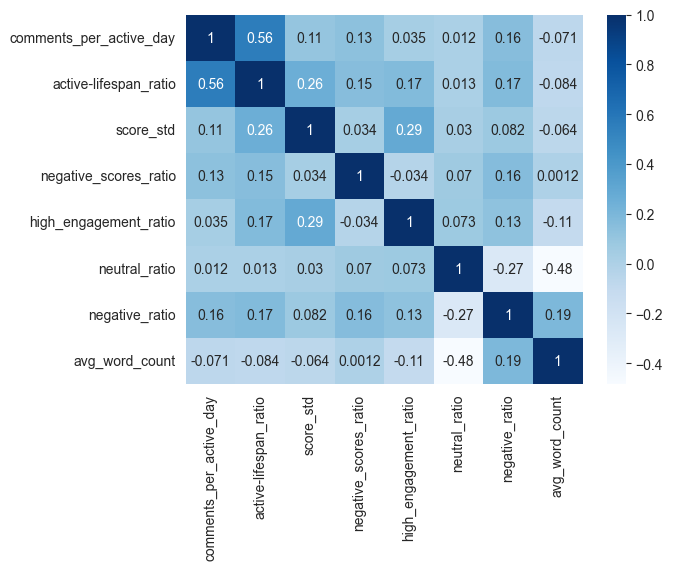

In [37]:
corr = features.drop(columns=['author', 'persona']+cols_to_drop, inplace=False).corr()

# plt.figure(figsize = (12, 8))
sns.heatmap(corr, annot=True, cmap='Blues')

Short comments are mostly neutral?

In [38]:
features.drop(columns=cols_to_drop, inplace=True)
features.head()

,author,persona,comments_per_active_day,active-lifespan_ratio,score_std,negative_scores_ratio,high_engagement_ratio,neutral_ratio,negative_ratio,avg_word_count
0,-Areopagan-,Persona_4,1.000000,0.025641,2.828427,0.000000,0.000000,0.500000,0.000000,68.500000
1,-BigSexy-,Persona_1,10.411765,0.894737,14.120726,0.018832,0.060264,0.316384,0.192090,26.438795
2,-BlitzN9ne,Persona_1,1.390000,0.207469,123.860868,0.035971,0.230216,0.460432,0.237410,20.510791
3,-CrestiaBell,Persona_1,9.096842,0.979381,451.595870,0.013191,0.226336,0.349456,0.231196,26.163157
4,-dyad-,Persona_2,1.234043,0.098121,21.063669,0.000000,0.224138,0.258621,0.241379,53.275862


### Persona based on activity & sentiment features

#### KMeans

In [39]:
features_scaled = features.copy().drop(columns=['author', 'persona'])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_scaled)

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(features_scaled)
features['kmeans_label'] = labels
features.head()

,author,persona,comments_per_active_day,active-lifespan_ratio,score_std,negative_scores_ratio,high_engagement_ratio,neutral_ratio,negative_ratio,avg_word_count,kmeans_label
0,-Areopagan-,Persona_4,1.000000,0.025641,2.828427,0.000000,0.000000,0.500000,0.000000,68.500000,3
1,-BigSexy-,Persona_1,10.411765,0.894737,14.120726,0.018832,0.060264,0.316384,0.192090,26.438795,2
2,-BlitzN9ne,Persona_1,1.390000,0.207469,123.860868,0.035971,0.230216,0.460432,0.237410,20.510791,1
3,-CrestiaBell,Persona_1,9.096842,0.979381,451.595870,0.013191,0.226336,0.349456,0.231196,26.163157,1
4,-dyad-,Persona_2,1.234043,0.098121,21.063669,0.000000,0.224138,0.258621,0.241379,53.275862,3


In [41]:
features['kmeans_label'].value_counts()

kmeans_label
3    533
0    349
1    217
2    166
Name: count, dtype: int64

In [106]:
corr = features[features_cols + ['kmeans_label']]
sns.heatmap(corr, annot=True, cmap='Blues')

KeyError: "['agreeableness', 'openness', 'conscientiousness', 'extraversion', 'neuroticism'] not in index"

In [42]:
features.drop(columns=['author', 'persona'], inplace=False).groupby(['kmeans_label']).mean()

,comments_per_active_day,active-lifespan_ratio,score_std,negative_scores_ratio,high_engagement_ratio,neutral_ratio,negative_ratio,avg_word_count
kmeans_label,,,,,,,,
0,2.353065,0.216121,12.750119,0.014928,0.088595,0.126292,0.296381,75.038594
1,3.539723,0.465045,112.290028,0.016124,0.248805,0.269924,0.252790,34.887186
2,10.444347,0.697294,36.989032,0.072693,0.102002,0.266109,0.289541,38.235104
3,2.035696,0.193929,13.178944,0.013222,0.083902,0.327479,0.175436,28.806690


Description:
- 0 Typical Reddit participants with moderate activity and relatively balanced emotional expression.
- 1 Users capable of generating highly visible or viral interactions. Their large score variability indicates inconsistent but occasionally very successful engagement with the community.
- 2 Very active, highly persistent users who participate frequently across many active days. Their elevated negative reception and sentiment suggest argumentative, confrontational, or highly opinionated behavior.
- 3 Low-intensity users characterized by emotionally neutral and socially low-impact participation.

The clustering procedure identified four distinct behavioral archetypes within Reddit users, differentiated primarily by activity intensity, engagement dynamics, and emotional expression. The largest cluster corresponded to low-intensity and emotionally neutral users, while smaller clusters captured highly engaged, socially influential, and hyperactive/polarizing behavioral profiles.

<Axes: xlabel='kmeans_label', ylabel='persona'>

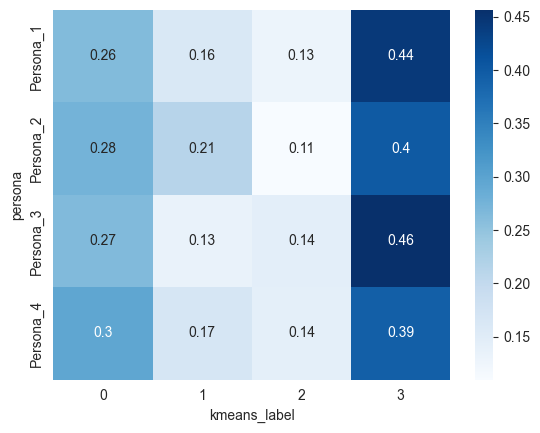

In [43]:
tab = pd.crosstab(features['persona'], features['kmeans_label'], normalize='index')
sns.heatmap(tab, annot=True, cmap='Blues')

This plot looks the same as for YSocial.

<Axes: xlabel='kmeans_label', ylabel='persona'>

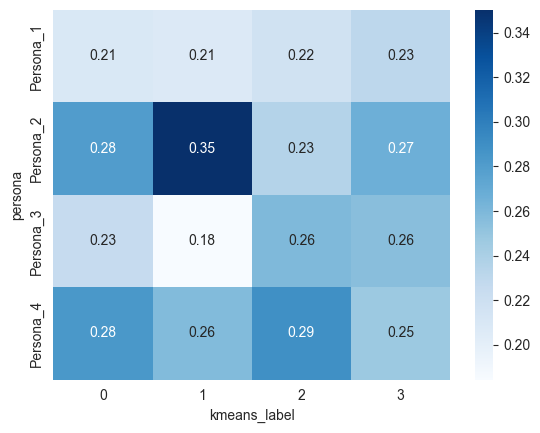

In [44]:
tab = pd.crosstab(features['persona'], features['kmeans_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

In [45]:
adjusted_rand_score(features['persona'], features['kmeans_label'])

-0.0006875191882689582

It's random mixing of B5 personas.

#### Hierarchical clustering

In [46]:
model = AgglomerativeClustering(
    n_clusters=4,          # same as KMeans for comparison
    linkage='ward'         # best default
    # linkage='average'   # more flexible
    # linkage='complete'  # tighter clusters
)

labels = model.fit_predict(features_scaled)

features['hier_label'] = labels

In [47]:
features['hier_label'].value_counts()

hier_label
2    404
0    360
1    341
3    160
Name: count, dtype: int64

In [48]:
features.drop(columns=['author', 'persona', 'kmeans_label'], inplace=False).groupby('hier_label').mean()

,comments_per_active_day,active-lifespan_ratio,score_std,negative_scores_ratio,high_engagement_ratio,neutral_ratio,negative_ratio,avg_word_count
hier_label,,,,,,,,
0,6.835479,0.651285,32.555976,0.027890,0.121260,0.264644,0.250154,38.209711
1,2.260474,0.164417,13.868423,0.037678,0.091521,0.176070,0.309778,66.710154
2,1.745946,0.127518,9.919336,0.006800,0.081046,0.303747,0.158457,32.264377
3,2.944818,0.333811,134.528682,0.013672,0.243483,0.270903,0.250983,37.009467


<Axes: xlabel='hier_label', ylabel='kmeans_label'>

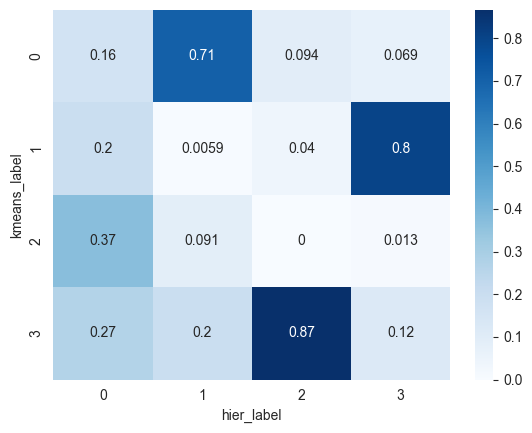

In [49]:
tab = pd.crosstab(features['kmeans_label'], features['hier_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

<Axes: xlabel='hier_label', ylabel='kmeans_label'>

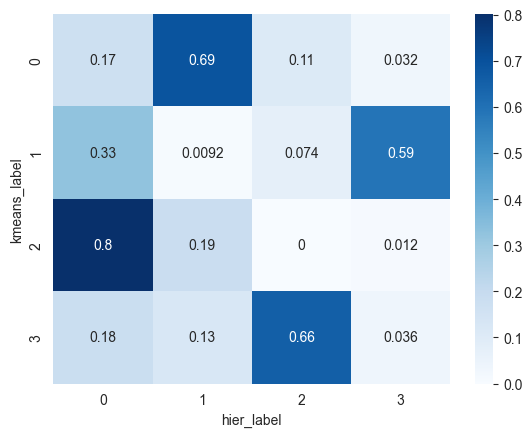

In [50]:
tab = pd.crosstab(features['kmeans_label'], features['hier_label'], normalize='index')
sns.heatmap(tab, annot=True, cmap='Blues')

In [51]:
print(f"Adjusted rand score:\nold persona vs. hierarchical clustering: {adjusted_rand_score(features['persona'], features['hier_label'])}")
print(f"KMeans vs. hierarchical clustering: {adjusted_rand_score(features['kmeans_label'], features['hier_label'])}")

Adjusted rand score:
old persona vs. hierarchical clustering: -0.00013933572136929086
KMeans vs. hierarchical clustering: 0.33404446637518703


It's the same relation as for YSocial.

### Interests extraction from *subreddit*

In [52]:
subreddit_count = comments['subreddit'].value_counts().reset_index(name='count')
subreddit_count.head()

,subreddit,count
0,OkCupid,58196
1,AskReddit,53308
2,popheads,40762
3,mbti,20487
4,DeadBedrooms,19192


9700 distinct subreddits

In [53]:
user_subreddit_counts = (
    comments.groupby(['author', 'subreddit'])
    .size()
    .reset_index(name='count')
)

In [54]:
user_subreddit_counts = user_subreddit_counts[
    user_subreddit_counts['count'] >= 3
]

len(user_subreddit_counts['subreddit'].unique())

5772

In [55]:
from social_graph.Reddit_interest_map import INTEREST_MAP

comments['interest'] = (
    comments['subreddit']
    .map(INTEREST_MAP)
    .fillna('other')
)

comments['interest'].value_counts()

interest
other                   141421
relationships           102176
entertainment            99921
politics                 83309
social_discussion        73872
personality_identity     71965
memes_humor              59263
gaming                   59127
sports                   57386
general_reddit           37773
geography_local          16424
technology               15232
mental_health            14949
lifestyle_health         14311
education_science        14287
news_world               14202
creative_hobbies         12856
finance_career            7614
ideology_religion         5327
Name: count, dtype: int64

In [65]:
len(set(INTEREST_MAP.keys()))

710

In [56]:
sub = comments[comments['interest'] == 'other']['subreddit'].value_counts().reset_index(name='count').sort_values(by='count', ascending=False)
sub

,subreddit,count
0,GirlGamers,449
1,minnesotavikings,376
2,Competitiveoverwatch,359
3,IncelTears,345
4,weddingplanning,326
...,...,...
8969,hellofellowkids,1
8968,bioniclememes,1
8967,redditwritesvsauce,1
8966,kaisamains,1


In [57]:
list(sub['subreddit'].head(200))

['GirlGamers',
 'minnesotavikings',
 'Competitiveoverwatch',
 'IncelTears',
 'weddingplanning',
 'Torontobluejays',
 'saltierthancrait',
 'GenZ',
 'CanadianForces',
 'Stormlords',
 'civ',
 'muacjdiscussion',
 'MHOCMeta',
 'HumansBeingBros',
 'AskMenOver30',
 'Rottweiler',
 'russian',
 'blogsnark',
 'Vechain',
 'shorthairedhotties',
 'boxoffice',
 'Teachers',
 'bangtan',
 'secretsanta',
 'suggestmeabook',
 'TexasTech',
 'ABoringDystopia',
 'Justrolledintotheshop',
 'asktransgender',
 'ModelUSGov',
 'printSF',
 'Seattle',
 'IdiotsInCars',
 'BigBrother',
 'ploungeafterdark',
 'thatHappened',
 'BetterEveryLoop',
 'China',
 'SoulCalibur',
 'blackcats',
 'runescape',
 'dragonballfighterz',
 'fcbayern',
 'Windows10',
 'elm',
 'TurkeyJerky',
 'polandball',
 'ibs',
 'OrthodoxChristianity',
 'darksouls3',
 'Terraria',
 'caps',
 'PartyParrot',
 'MorbidReality',
 'typescript',
 'assassinscreed',
 'GoldandBlack',
 'whitepeoplegifs',
 'IWantOut',
 'AppleWatch',
 'LivestreamFail',
 'buildapcsales',
 

In [58]:
interest_profile = (
    comments.groupby(["author", "interest"])
    .size()
    .unstack(fill_value=0)
)

interest_profile = interest_profile.div(
    interest_profile.sum(axis=1),
    axis=0
)

main_interests = interest_profile.idxmax(axis=1).reset_index(name='main_interest')
main_interests.head()

,author,main_interest
0,-Areopagan-,politics
1,-BigSexy-,ideology_religion
2,-BlitzN9ne,other
3,-CrestiaBell,social_discussion
4,-dyad-,entertainment


In [66]:
features = features.merge(main_interests, on='author', how='left')
features.head()

,author,persona,comments_per_active_day,active-lifespan_ratio,score_std,negative_scores_ratio,high_engagement_ratio,neutral_ratio,negative_ratio,avg_word_count,kmeans_label,hier_label,main_interest
0,-Areopagan-,Persona_4,1.000000,0.025641,2.828427,0.000000,0.000000,0.500000,0.000000,68.500000,3,2,politics
1,-BigSexy-,Persona_1,10.411765,0.894737,14.120726,0.018832,0.060264,0.316384,0.192090,26.438795,2,0,ideology_religion
2,-BlitzN9ne,Persona_1,1.390000,0.207469,123.860868,0.035971,0.230216,0.460432,0.237410,20.510791,1,3,other
3,-CrestiaBell,Persona_1,9.096842,0.979381,451.595870,0.013191,0.226336,0.349456,0.231196,26.163157,1,3,social_discussion
4,-dyad-,Persona_2,1.234043,0.098121,21.063669,0.000000,0.224138,0.258621,0.241379,53.275862,3,2,entertainment


In [69]:
features['main_interest'].value_counts()

main_interest
other                   491
personality_identity    155
politics                114
gaming                   91
entertainment            83
social_discussion        59
relationships            52
memes_humor              47
sports                   43
general_reddit           26
mental_health            19
geography_local          16
lifestyle_health         15
creative_hobbies         13
technology               12
ideology_religion         9
finance_career            8
education_science         7
news_world                5
Name: count, dtype: int64

In [120]:
plot_interest_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'interest': valid_users['main_interest']
})

plot_pca(plot_interest_df, colour_by='interest')

ValueError: array length 1568 does not match index length 1265